# Detección de patrones y valores atípicos en el mercado inmobiliario de Melbourne mediante Machine Learning no supervisado

**Actividad 1 Proyecto ETL y EDA**
607526/INTRODUCCION A MACHINE LEARNING

**Integrantes:**
- EDWIN SEBASTIAN RINCON RAMIREZ
- SERGIO ESTEBAN BELLO GOMEZ

**Programa:** Ingeniería de Sistemas y Computación
**Fecha de entrega:** 04/09/2026

---


## 1. Título

**Detección de patrones y valores atípicos en el mercado inmobiliario de Melbourne mediante Machine Learning no supervisado**


## 2. Objetivo general

Analizar el comportamiento del mercado inmobiliario de Melbourne mediante un proceso de extracción,
exploración y preprocesamiento de datos, que permita identificar la calidad inicial del dataset y sentar
las bases para, en una fase posterior (Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS), detectar observaciones atípicas y patrones relevantes
que apoyen la toma de decisiones inmobiliarias.


## 3. Objetivos específicos

1. Extraer y describir la estructura del dataset de vivienda de Melbourne, identificando su calidad inicial
   (valores nulos, registros duplicados, tipos de datos) sin alterar el conjunto de datos original.
2. Realizar un análisis exploratorio de datos (EDA) que revele la distribución, dispersión y relaciones
   entre las variables numéricas (precio, distancia, tamaño del terreno, área construida) y categóricas
   (tipo de propiedad, región, método de venta) más relevantes para el problema.
3. Identificar visualmente posibles valores atípicos y patrones geográficos (mediante latitud y longitud)
   que sustenten el proceso de preprocesamiento, escalamiento y detección de anomalías de la Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS.


## 4. Problemática

El mercado inmobiliario de Melbourne se caracteriza por una alta rotación de propiedades y una fuerte
variabilidad de precios entre suburbios, tipos de vivienda y métodos de venta. Agencias inmobiliarias,
compradores y entidades de planeación urbana necesitan comprender estas dinámicas para tomar
decisiones informadas, pero los registros de transacciones suelen presentar información incompleta
(por ejemplo, área construida o año de construcción sin diligenciar) y valores extremos que pueden
corresponder tanto a errores de captura como a propiedades genuinamente atípicas (de lujo, en muy mal
estado, o con condiciones excepcionales de ubicación).

Sin un proceso sistemático de extracción, exploración y limpieza de datos, estas inconsistencias no se
detectan a tiempo: se toman decisiones sobre información parcial, se entrenan modelos predictivos sobre
datos sin depurar y se pierde la oportunidad de identificar tanto errores como observaciones
verdaderamente interesantes (propiedades sub o sobrevaloradas). Este proyecto aborda esa problemática
construyendo, en dos fases, un pipeline reproducible de preparación de datos: primero mediante un
diagnóstico ETL y EDA (Actividad 1), y después mediante preprocesamiento, escalamiento y detección
de anomalías con métodos estadísticos y de aprendizaje no supervisado (Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS).


## 5. Tecnologías

- **Lenguaje:** Python 3.12
- **Entorno de ejecución:** Jupyter Notebook / JupyterLab
- **Manipulación de datos:** Pandas, NumPy
- **Visualización:** Matplotlib, Seaborn
- **Preprocesamiento y detección de anomalías (Actividad 2):** Scikit-learn, SciPy


## 6. Propuesta de solución

Se implementará un pipeline en Python sobre Jupyter Notebook que, en esta primera fase, extraiga el
dataset *Melbourne Housing Snapshot* y realice un diagnóstico de calidad de datos junto con un análisis
exploratorio (EDA) completamente documentado en Markdown. Los hallazgos de esta fase (variables con
valores nulos, distribución de precios, relaciones entre variables, indicios visuales de outliers y patrones
geográficos) serán el insumo directo de la Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS, en la que se aplicarán técnicas de imputación, normalización/estandarización y detección de anomalías (IQR, Z-score, Isolation Forest y DBSCAN)
sobre las mismas variables aquí exploradas.


## 7. Extracción inicial de los datos

**Fuente de los datos:** *Melbourne Housing Snapshot* (Kaggle, usuario `dansbecker`,
<https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot>). Es una instantánea estática
creada en septiembre de 2017 a partir de datos de venta de vivienda publicados semanalmente en
Domain.com.au (dataset original recopilado por Tony Pino). Contiene **21 variables** y aproximadamente
**13.580 registros** (se excluyeron del snapshot las propiedades sin precio registrado).

**Cómo obtener el archivo:**
1. Ingresa al enlace del dataset en Kaggle y se debe iniciar sesión.
2. Descarga el archivo `melb_data.csv`.
3. Colócalo en la carpeta `data/` de la raíz del proyecto (es decir, un nivel arriba de `notebooks/`,
   como `cadi-ml-melbourne/data/melb_data.csv`). VS Code ejecuta el notebook usando como carpeta de
   trabajo la carpeta donde está el `.ipynb` (`notebooks/`), por eso la celda siguiente usa la ruta
   `../data/melb_data.csv` para subir un nivel y entrar a `data/`.

A continuación se importan las librerías necesarias para todo el notebook.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


Cargamos el dataset y conservamos una copia intacta (`df_raw`) que nunca se modificará, para poder
comparar en cualquier momento contra el estado original de los datos.


In [17]:
# Ajusta la ruta si tu archivo está en otra ubicación
df = pd.read_csv("../data/melb_data.csv")

# Copia del dataset original, sin modificaciones, como referencia
df_raw = df.copy()

print("Dataset cargado correctamente.")


Dataset cargado correctamente.


Mostramos una muestra inicial de los datos para reconocer visualmente las columnas y el tipo de
información que contiene cada una.


In [18]:
df.head(10)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0
5,Abbotsford,129 Charles St,2,h,941000.0,S,Jellis,7/05/2016,2.5,3067.0,2.0,1.0,0.0,181.0,NaN,NaN,Yarra,-37.8041,144.9953,Northern Metropolitan,4019.0
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,7/05/2016,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.8024,144.9993,Northern Metropolitan,4019.0
7,Abbotsford,98 Charles St,2,h,1636000.0,S,Nelson,8/10/2016,2.5,3067.0,2.0,1.0,2.0,256.0,107.0,1890.0,Yarra,-37.8060,144.9954,Northern Metropolitan,4019.0
8,Abbotsford,6/241 Nicholson St,1,u,300000.0,S,Biggin,8/10/2016,2.5,3067.0,1.0,1.0,1.0,0.0,NaN,NaN,Yarra,-37.8008,144.9973,Northern Metropolitan,4019.0
9,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,8/10/2016,2.5,3067.0,3.0,1.0,2.0,220.0,75.0,1900.0,Yarra,-37.8010,144.9989,Northern Metropolitan,4019.0


Verificamos el número de registros y variables, y el tipo de dato asignado a cada columna. Esto nos
permite distinguir de entrada qué variables son numéricas, cuáles categóricas (`object`) y cuáles podrían
necesitar una conversión de tipo (por ejemplo, `Date`).


In [19]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de variables:  {df.shape[1]}")
print()
df.dtypes


Número de registros: 13580
Número de variables:  21



Suburb               str
Address              str
Rooms              int64
Type                 str
Price            float64
Method               str
SellerG              str
Date                 str
Distance         float64
Postcode         float64
Bedroom2         float64
Bathroom         float64
Car              float64
Landsize         float64
BuildingArea     float64
YearBuilt        float64
CouncilArea          str
Lattitude        float64
Longtitude       float64
Regionname           str
Propertycount    float64
dtype: object

Diagnosticamos la presencia de valores nulos por variable (cantidad y porcentaje) y de registros
duplicados. Este resultado es la base directa del diagnóstico de nulos que se profundizará en la
Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS.


In [20]:
null_summary = df.isna().sum().to_frame("nulos")
null_summary["porcentaje"] = (null_summary["nulos"] / len(df) * 100).round(2)
null_summary = null_summary.sort_values("porcentaje", ascending=False)
display(null_summary)

print(f"\nRegistros duplicados: {df.duplicated().sum()}")


,nulos,porcentaje
BuildingArea,6450,47.50
YearBuilt,5375,39.58
CouncilArea,1369,10.08
Car,62,0.46
Suburb,0,0.00
Price,0,0.00
Type,0,0.00
Rooms,0,0.00
Address,0,0.00
Distance,0,0.00



Registros duplicados: 0


> **Nota de interpretación:** indica aquí qué variables concentran la mayor
> cantidad de nulos, si tiene sentido imputarlas o no (por ejemplo, un identificador no debería imputarse),
> y si el número de duplicados es significativo frente al tamaño del dataset.


## 8. Análisis Exploratorio de Datos (EDA) inicial

### 8.1 Estadísticos descriptivos de las variables numéricas


In [21]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


### 8.2 Frecuencias de las variables categóricas relevantes

Revisamos la distribución de `Type` (tipo de propiedad: h = house, u = unit/dúplex, t = townhouse),
`Method` (método de venta), `Regionname` (región) y `CouncilArea` (municipio), incluyendo los valores
nulos en el conteo (`dropna=False`) para no ocultarlos.


In [22]:
for col in ["Type", "Method", "Regionname", "CouncilArea"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()


--- Type ---
Type
h    9449
u    3017
t    1114
Name: count, dtype: int64

--- Method ---
Method
S     9022
SP    1703
PI    1564
VB    1199
SA      92
Name: count, dtype: int64

--- Regionname ---
Regionname
Southern Metropolitan         4695
Northern Metropolitan         3890
Western Metropolitan          2948
Eastern Metropolitan          1471
South-Eastern Metropolitan     450
Eastern Victoria                53
Northern Victoria               41
Western Victoria                32
Name: count, dtype: int64

--- CouncilArea ---
CouncilArea
NaN                  1369
Moreland             1163
Boroondara           1160
Moonee Valley         997
Darebin               934
Glen Eira             848
Stonnington           719
Maribyrnong           692
Yarra                 647
Port Phillip          628
Banyule               594
Bayside               489
Melbourne             470
Hobsons Bay           434
Brimbank              424
Monash                333
Manningham            311
Whitehorse

### 8.3 Distribución de las variables numéricas clave

Histogramas de `Price`, `Landsize`, `BuildingArea` y `Distance`. Se usa `dropna()` en cada variable para
que los valores nulos no interfieran en la visualización (el tratamiento formal de esos nulos se hace en
la Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS).


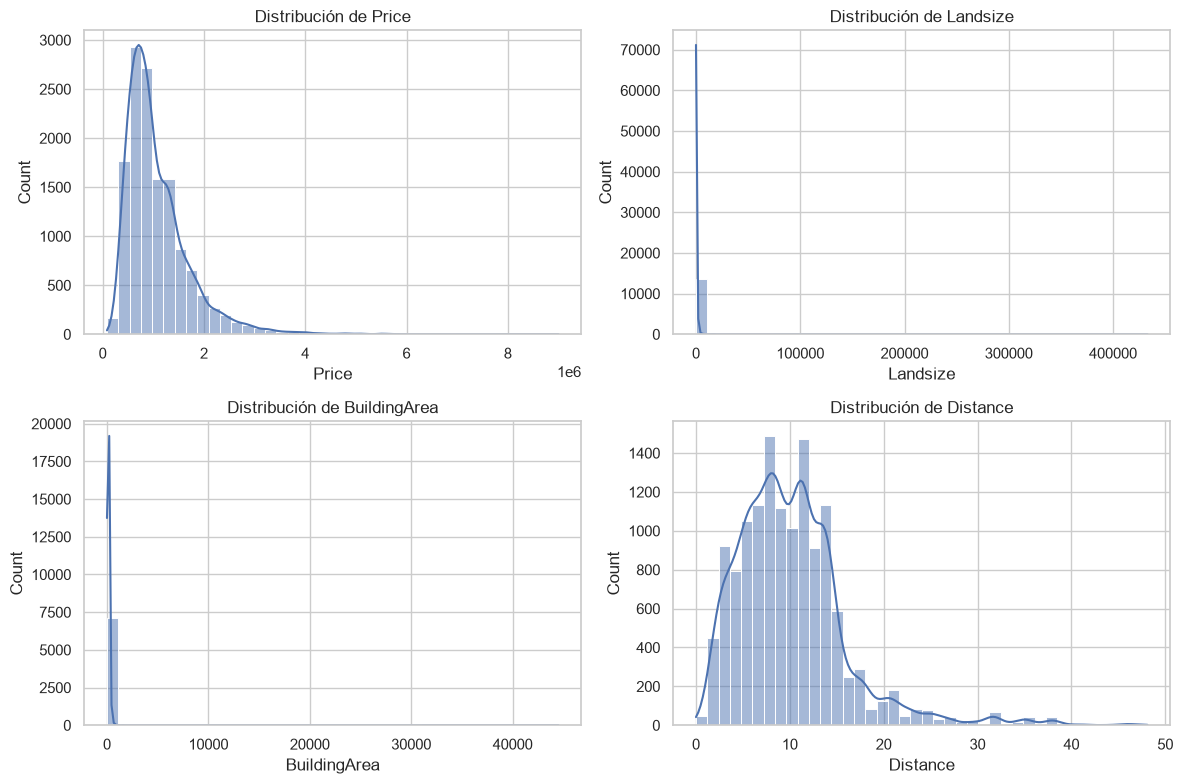

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
variables = ["Price", "Landsize", "BuildingArea", "Distance"]

for ax, var in zip(axes.flatten(), variables):
    sns.histplot(df[var].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(f"Distribución de {var}")

plt.tight_layout()
plt.show()


### 8.4 Boxplots para identificar posibles valores atípicos

Boxplot del precio según el tipo de propiedad y según la región. Los puntos fuera de los bigotes son
candidatos visuales a outliers que se formalizarán con IQR y Z-score en la Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS.


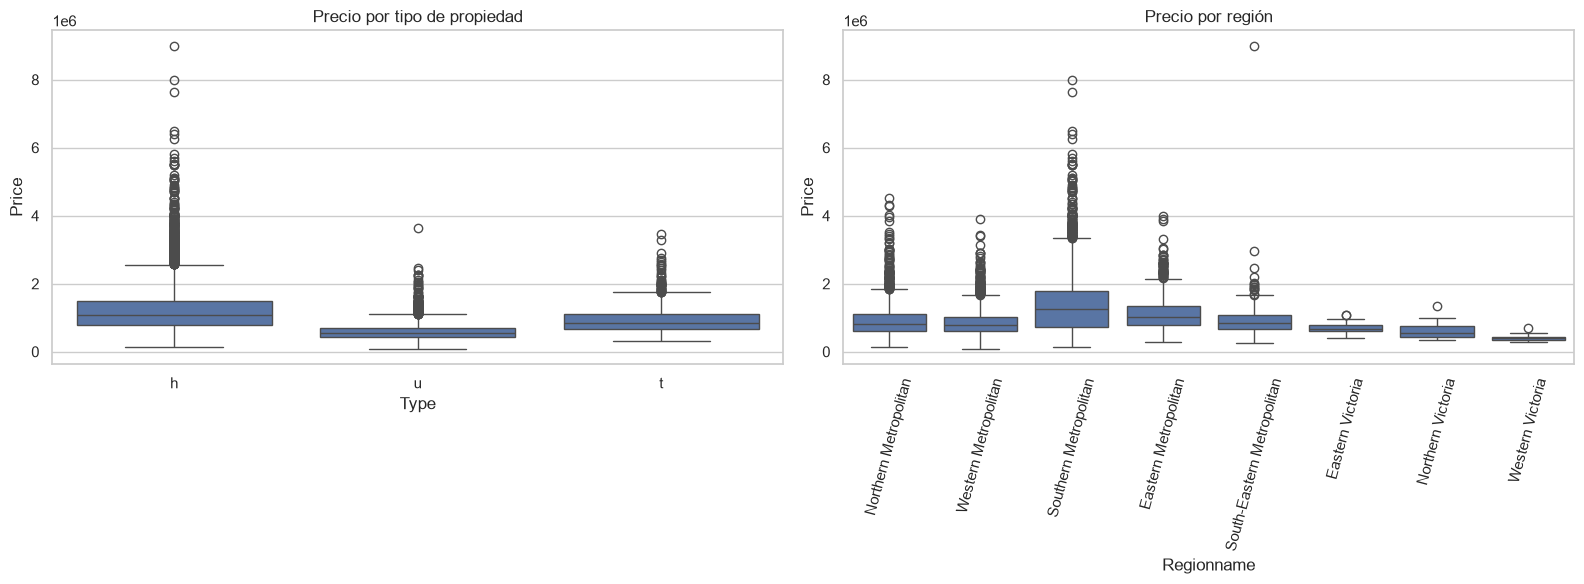

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x="Type", y="Price", ax=axes[0])
axes[0].set_title("Precio por tipo de propiedad")

sns.boxplot(data=df, x="Regionname", y="Price", ax=axes[1])
axes[1].set_title("Precio por región")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()


### 8.5 Correlación entre variables numéricas


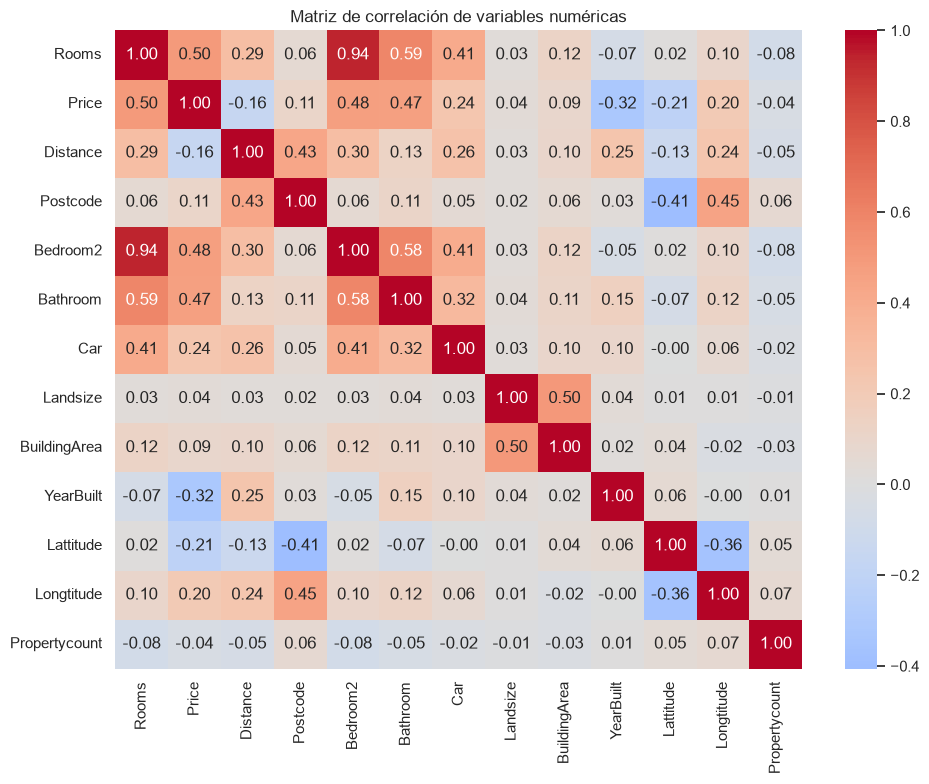

In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.show()


### 8.6 Patrón geográfico (vista previa para DBSCAN en Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS)

Ubicamos cada propiedad según su latitud y longitud, coloreando por precio. Esta visualización es
particularmente relevante porque `Lattitude` y `Longtitude` serán dos de las variables que usaremos con
DBSCAN en Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS para detectar agrupamientos geográficos y puntos de ruido (anomalías
espaciales).


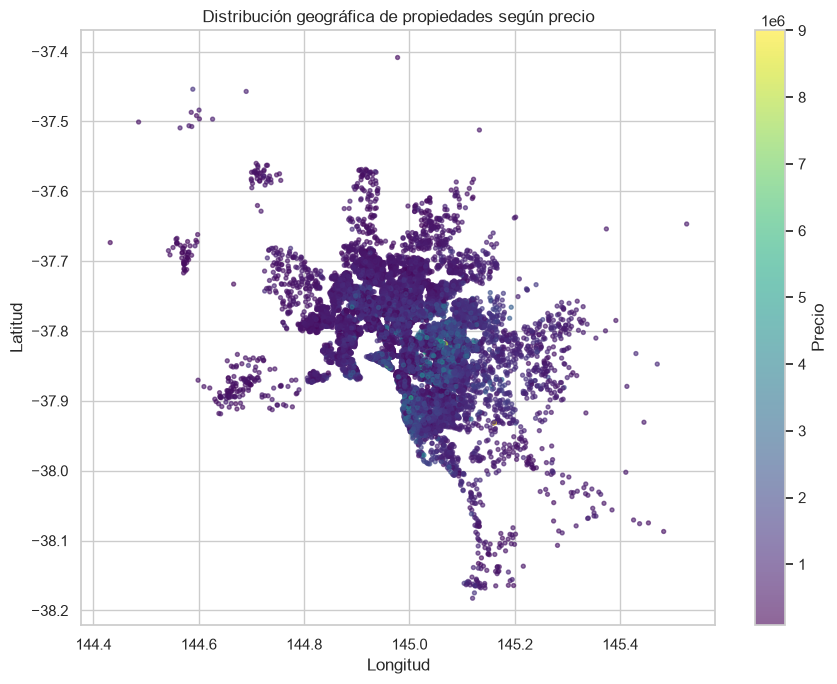

In [26]:
geo = df.dropna(subset=["Lattitude", "Longtitude", "Price"])

plt.figure(figsize=(9, 7))
sc = plt.scatter(geo["Longtitude"], geo["Lattitude"], c=geo["Price"],
                  cmap="viridis", s=8, alpha=0.6)
plt.colorbar(sc, label="Precio")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Distribución geográfica de propiedades según precio")
plt.tight_layout()
plt.show()


## 9. Hallazgos principales

- **Calidad de los datos:** el dataset no presenta registros duplicados. Los valores nulos se concentran en
  cuatro variables: `BuildingArea` (47.50 %), `YearBuilt` (39.58 %), `CouncilArea` (10.08 %) y `Car`
  (0.46 %); el resto de variables no tiene nulos. No sería apropiado imputar variables identificadoras
  como `Address` o `SellerG`, ya que no tiene sentido conceptual asignarles un valor "promedio" o "más
  frecuente".
- **Distribución de precios:** `Price` muestra un sesgo positivo marcado la media (1.075.684) es mayor
  que la mediana (903.000) con una cola larga hacia la derecha que llega hasta 9.000.000, evidenciando
  un pequeño grupo de propiedades de muy alto valor frente a la mayoría del mercado.
- **Relación tipo de propiedad / precio:** el tipo `h` (house) concentra la mayor dispersión de precios y
  la mayor cantidad de valores atípicos visuales en el boxplot (hasta cerca de 9.000.000), mientras que
  `u` (unit/dúplex) tiene la mediana más baja (-600.000) y una caja notablemente más acotada.
- **Relación región / precio:** `Southern Metropolitan` concentra los precios medianos más altos y más
  outliers superiores (hasta ~8.000.000). Llama la atención un valor extremo cercano a 9.000.000 en
  `South-Eastern Metropolitan`, región cuya mediana ronda los 900.000 un candidato claro a valor
  atípico que se profundizará en la Actividad 2.
- **Correlaciones relevantes:** `Price` se correlaciona más con `Rooms` (0.50), `Bedroom2` (0.48) y
  `Bathroom` (0.47); `Distance` (-0.16) y `YearBuilt` (-0.32) muestran correlación negativa. Se destaca
  una correlación muy alta entre `Rooms` y `Bedroom2` (0.94), lo que sugiere que ambas variables miden
  prácticamente lo mismo (redundancia a considerar en una futura reducción de dimensionalidad).
- **Patrón geográfico:** las propiedades forman un núcleo denso en el centro de Melbourne y varios grupos
  satélite más dispersos hacia el norte, oeste y sureste, separados por zonas de baja densidad un
  patrón de densidad variable, justo el tipo de estructura donde DBSCAN suele superar a algoritmos como
  K-means.
- **Valores especialmente atípicos detectados:** `YearBuilt` tiene un valor mínimo de 1196, un año
  imposible para una vivienda en Melbourne (fundada en 1835), lo que indica un evidente error de
  captura. `Landsize` y `BuildingArea` presentan máximos extremos (433.014 y 44.515 respectivamente)
  frente a percentiles 75 de apenas 651 y 174, distorsionando por completo sus histogramas. Estos casos
  serán tratados formalmente con IQR, Z-score, Isolation Forest y DBSCAN en Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS.

## 10. Próximos pasos (enlace con la Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS)

A partir de estos hallazgos, en Semana 3: PREPROCESAMIENTO, IMPUTACIÓN Y DETECCIÓN DE OUTLIERS se construirá un pipeline de preprocesamiento sobre este
mismo dataset: diagnóstico e imputación formal de los valores nulos identificados en `Car`,
`BuildingArea`, `YearBuilt` y `CouncilArea`; estandarización de las variables numéricas; y detección
comparativa de outliers mediante IQR, Z-score, Isolation Forest y DBSCAN este último aprovechando
directamente el patrón geográfico explorado en la sección 8.6.
